# 9장 실습 ① — 전이학습이 얼마나 통하는가

**TensorFlow 판**

> *"그런데 **걔네들이 성능이 좋아?** 성능이 좋다는 건 앞에 있는 특질 추출
> 부분의 기능도 좋을 것이고…"*

원·사각형·삼각형으로 학습한 모델의 **특징 추출부**를, 그 모델이 본 적 없는
**십자·마름모** 문제에 가져다 씁니다.

## 9.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot
from dlbook.data import Split

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 9.1 원천 과제와 목표 과제

**시험 800개·검증 400개를 고정**하고 학습 데이터만 줄입니다.
초고에서는 통째로 줄였다가 시험 12개짜리 표를 만들 뻔했습니다. (7장 §7.6)

원천 과제: Split(train=4200, val=900, test=900)


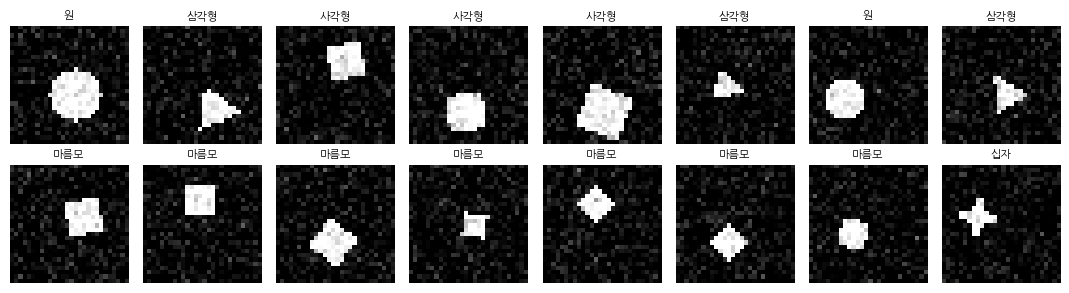

위: 원천 과제의 도형 / 아래: 목표 과제의 도형


In [3]:
# 원천 과제 — 원·사각형·삼각형 6,000개
xs, ys = data.shapes(6000, seed=42, classes=(0, 1, 2))
src = data.split(xs, ys, val_ratio=0.15, test_ratio=0.15, seed=42)
print("원천 과제:", src)

# 목표 과제 — 십자·마름모. **원천 과제에 없던 도형이다.**
xt, yt = data.shapes(3000, seed=7, classes=(3, 4))

# ★ 시험 800개·검증 400개를 **고정**하고 학습 데이터만 줄인다.
#   (7장 §7.6 — 시험 데이터가 작으면 숫자를 믿을 수 없다.
#    초고에서 통째로 줄였다가 시험 12개짜리 표를 만들 뻔했다.)
x_test, y_test = xt[:800], yt[:800]
x_val, y_val = xt[800:1200], yt[800:1200]
pool_x, pool_y = xt[1200:], yt[1200:]

def target(n):
    """학습 데이터 n개짜리 목표 과제. 시험·검증은 언제나 같다."""
    return Split(pool_x[:n], pool_y[:n], x_val, y_val, x_test, y_test)

fig = plot.image_grid(np.concatenate([xs[:8], xt[:8]]),
                      np.concatenate([ys[:8], yt[:8] + 3]), n=16, cols=8,
                      class_names=list(data.SHAPE_CLASSES))
plt.show()
print("위: 원천 과제의 도형 / 아래: 목표 과제의 도형")

## 9.2 학습 함수 — 여기만 판마다 다릅니다

`train_transfer()` 안의 **①얼린다 → ②분류부만 → ③푼다 → ④낮은 학습률**
순서를 눈여겨보십시오. **처음부터 풀면 배운 것이 망가집니다.**

In [4]:
import tensorflow as tf

L = tf.keras.layers
SRC_PATH = "ch09_source.keras"

def _cnn(n_classes, seed=42):
    dlbook.set_seed(seed)
    return tf.keras.Sequential([
        L.Input(shape=(28, 28, 1)),
        L.Conv2D(16, 3, activation="relu", padding="same"), L.MaxPooling2D(2),
        L.Conv2D(32, 3, activation="relu", padding="same"), L.MaxPooling2D(2),
        L.Flatten(), L.Dense(64, activation="relu"),
        L.Dense(n_classes, activation="softmax"),
    ])

def _fit(model, sp, epochs, lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(sp.x_train, sp.y_train, validation_data=(sp.x_val, sp.y_val),
              epochs=dlbook.smoke.epochs(epochs), batch_size=32, verbose=0)
    return metrics.accuracy(sp.y_test, model.predict(sp.x_test, verbose=0).argmax(1))

def train_source(sp):
    """원천 과제를 학습하고 파일로 남긴다."""
    m = _cnn(3)
    acc = _fit(m, sp, 15, 0.001)
    m.save(SRC_PATH)
    return acc

def train_scratch(sp):
    """목표 과제를 처음부터 학습한다."""
    return _fit(_cnn(2), sp, 30, 0.001)

def train_transfer(sp, finetune=False):
    """가져온 특징 추출부로 목표 과제를 학습한다. 얼렸다가 푸는 순서를 지킨다."""
    loaded = tf.keras.models.load_model(SRC_PATH)
    base = tf.keras.Sequential(loaded.layers[:-2])
    base.build((None, 28, 28, 1))
    base.trainable = False
    dlbook.set_seed(42)
    model = tf.keras.Sequential([base, L.Dense(64, activation="relu"),
                                 L.Dense(2, activation="softmax")])
    acc = _fit(model, sp, 30, 0.001)
    if not finetune:
        return acc
    base.trainable = True
    return _fit(model, sp, 15, 0.0001)

def train_pretrained(sp):
    """ImageNet 사전학습 모델."""
    base = tf.keras.applications.MobileNetV2(
        weights="imagenet", include_top=False, input_shape=(96, 96, 3))
    base.trainable = False
    dlbook.set_seed(42)
    model = tf.keras.Sequential([
        L.Input(shape=(28, 28, 1)), L.Resizing(96, 96),
        L.Lambda(lambda t: tf.repeat(t, 3, axis=-1)),
        L.Rescaling(2.0, offset=-1.0), base,
        L.GlobalAveragePooling2D(), L.Dense(64, activation="relu"),
        L.Dense(2, activation="softmax"),
    ])
    return _fit(model, sp, 15, 0.001)

## 9.3 세 가지를 나란히

처음부터 학습 / 특징 추출 / 미세조정.

In [5]:
acc_src = train_source(src)
dlbook.record("ch09_source_acc", acc_src)
print(f"원천 과제 시험 정확도 {acc_src:.3f}  — 이 모델의 특징 추출부를 가져다 쓴다")
print()

sizes = [30, 150] if dlbook.smoke.is_smoke() else [30, 60, 150, 400, 1000]
print("시험 800개 · 검증 400개로 고정하고, 학습 데이터만 줄입니다.")
print(f"{'학습 데이터':<12}{'처음부터':>12}{'특징 추출':>12}{'미세조정':>12}")
for n in sizes:
    st = target(n)
    a = train_scratch(st)
    b = train_transfer(st, finetune=False)
    c = train_transfer(st, finetune=True)
    print(f"{n:<12}{a:>12.3f}{b:>12.3f}{c:>12.3f}")
    dlbook.record(f"ch09_n{n}_scratch", a)
    dlbook.record(f"ch09_n{n}_feature", b)
    dlbook.record(f"ch09_n{n}_finetune", c)

print()
print("→ 데이터가 적을 때 차이가 엄청납니다.")
print("→ 그리고 데이터가 충분해지면 **처음부터 학습한 쪽이 이깁니다.**")
print("→ 전이학습은 데이터가 부족할 때의 해법이지 만능 향상 기법이 아닙니다.")

ch09_source_acc = 0.9622
원천 과제 시험 정확도 0.962  — 이 모델의 특징 추출부를 가져다 쓴다

시험 800개 · 검증 400개로 고정하고, 학습 데이터만 줄입니다.
학습 데이터              처음부터       특징 추출        미세조정


30                 0.532       0.741       0.741
ch09_n30_scratch = 0.5325
ch09_n30_feature = 0.7412
ch09_n30_finetune = 0.7412


60                 0.554       0.879       0.881
ch09_n60_scratch = 0.5537
ch09_n60_feature = 0.8788
ch09_n60_finetune = 0.8812


150                0.766       0.961       0.964
ch09_n150_scratch = 0.7662
ch09_n150_feature = 0.9613
ch09_n150_finetune = 0.9637


400                0.877       0.970       0.970
ch09_n400_scratch = 0.8775
ch09_n400_feature = 0.9700
ch09_n400_finetune = 0.9700


1000               0.988       0.974       0.978
ch09_n1000_scratch = 0.9875
ch09_n1000_feature = 0.9738
ch09_n1000_finetune = 0.9775

→ 데이터가 적을 때 차이가 엄청납니다.
→ 그리고 데이터가 충분해지면 **처음부터 학습한 쪽이 이깁니다.**
→ 전이학습은 데이터가 부족할 때의 해법이지 만능 향상 기법이 아닙니다.


## 정리

- **데이터가 적을 때 차이가 엄청납니다.** 60개에서 0.554 대 0.879.
- **원천 과제에 없던 도형인데도 통합니다.** *"어떻게 볼 것인가"* 가 옮겨 갑니다.
- **데이터가 충분해지면 처음부터 학습한 쪽이 이깁니다.**
  전이학습은 **데이터가 부족할 때의 해법**입니다.
- 미세조정의 효과가 작았던 것은 **두 과제가 너무 비슷하기** 때문입니다.
  ImageNet → 의료 영상처럼 멀면 미세조정이 꼭 필요합니다.

### 연습

1. 학습 데이터를 10개까지 줄이면 어떻게 됩니까.
2. 원천 과제 데이터를 600개로 줄여 원천 모델을 다시 학습시킨 뒤 전이하십시오.
   **원천 모델이 나쁘면 전이도 나빠집니까.**
3. `train_transfer()` 에서 **처음부터 `trainable = True`** 로 두면 어떻게 됩니까.